# Challenge 2: Supervised Learning - Music Classification and Regression

This report addresses the 2025 Challenge 2, focusing on supervised learning for music genre classification and track duration prediction. We use the provided datasets, with a focus on tracks present in the Echonest features (echo). Since the spectral_features.tsv file was not available in the provided attachments, we proceed without it for this analysis (it can be added later if needed). All code is provided in Python using pandas, numpy, and scikit-learn (note: scikit-learn is assumed to be available for local execution; if not, install it via pip). The report is structured according to the phases in the guideline.

We assume good ML practices, such as using k-fold cross-validation to prevent data leakage and ensure reproducibility. The deadline is December 5, 2025, 11:30pm, so this is submitted in time (current date: December 3, 2025).

## 1. Loading and merging the datasets

We are provided with four files:  
- `tracks.tsv` : metadata, artist, album, listens, primary genre (`genre_top`)  
- `echonest_features.tsv` : high-level audio descriptors (danceability, energy, tempo…)  
- `spectral_features.tsv` : low-level spectral statistics  
- `genres.csv` : hierarchical taxonomy of genres  

All three feature tables share the same key: **track_id**.

We begin by loading the three main tables and merging them into a single dataset.


In [192]:
# Cell 2: Imports and settings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

In [193]:
# Cell 3: Load data
tracks = pd.read_csv("tracks.tsv", sep="\t")
echo = pd.read_csv("echonest_features.tsv", sep="\t")
spectral = pd.read_csv("spectral_features.tsv", sep="\t")
genres_df = pd.read_csv("genres.csv")  # taxonomy

# Merge audio features into one table
audio = echo.merge(spectral, on="track_id", how="left")

# Merge metadata + audio
df = audio.merge(tracks, on="track_id", how="left")

print('echonest features shape:', echo.shape)
print('spectral features shape:', spectral.shape)
print('tracks shape:', tracks.shape)
print('final dataframe shape:', df.shape)

echonest features shape: (11440, 9)
spectral features shape: (99995, 22)
tracks shape: (99995, 14)
final dataframe shape: (11440, 43)


# 2. Data Inspection

We explore the first few rows, column types, and summary statistics to understand the dataset structure and spot potential issues.

- `.head()`: Quick look at sample rows

- `.dtypes`: Column types

- `.describe()`: Summary statistics for numeric columns

- `.isna().sum()`: Missing values per column

In [194]:
# Show first few rows
df.head()

,track_id,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence,spectral_bandwidth_kurtosis_01,...,artist_longitude,artist_name,duration,favorites,genre_top,genres,genres_all,interest,listens,title
0,11870,0.373039,0.429892,0.645929,0.769285,0.195042,0.101240,159.908,0.474554,1.386746,...,NaN,Wildahead Portibeast,131.0,0.0,Hip-Hop,[21],[21],733.0,218.0,What The Truth Should Be
1,11871,0.908215,0.427918,0.694364,0.950413,0.269082,0.180927,188.077,0.585049,0.988129,...,NaN,Wildahead Portibeast,185.0,0.0,Hip-Hop,[21],[21],753.0,267.0,It's True
2,11872,0.204111,0.501329,0.608690,0.725811,0.125451,0.623711,137.676,0.522381,-0.288111,...,NaN,Wildahead Portibeast,183.0,0.0,Hip-Hop,[21],[21],744.0,223.0,Pedestal
3,11873,0.464478,0.419687,0.743163,0.786033,0.214622,0.142762,79.371,0.644394,0.013341,...,NaN,Wildahead Portibeast,213.0,3.0,Hip-Hop,[21],[21],936.0,245.0,Timetomoveover (prod. 6th Sense)
4,11874,0.921960,0.350383,0.588584,0.861204,0.120561,0.187306,190.518,0.537996,2.176594,...,NaN,Wildahead Portibeast,162.0,0.0,Hip-Hop,[21],[21],861.0,192.0,Stranger feat. 6th Sense


In [195]:
# Check for types of each column
df.dtypes

track_id                            int64
acousticness                      float64
danceability                      float64
energy                            float64
instrumentalness                  float64
liveness                          float64
speechiness                       float64
tempo                             float64
valence                           float64
spectral_bandwidth_kurtosis_01    float64
spectral_bandwidth_max_01         float64
spectral_bandwidth_mean_01        float64
spectral_bandwidth_median_01      float64
spectral_bandwidth_min_01         float64
spectral_bandwidth_skew_01        float64
spectral_bandwidth_std_01         float64
spectral_centroid_kurtosis_01     float64
spectral_centroid_max_01          float64
spectral_centroid_mean_01         float64
spectral_centroid_median_01       float64
spectral_centroid_min_01          float64
spectral_centroid_skew_01         float64
spectral_centroid_std_01          float64
spectral_rolloff_kurtosis_01      

In [196]:
# Summary statistics for numeric columns
df.describe()


,track_id,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence,spectral_bandwidth_kurtosis_01,...,spectral_rolloff_min_01,spectral_rolloff_skew_01,spectral_rolloff_std_01,album_tracks,artist_latitude,artist_longitude,duration,favorites,interest,listens
count,11440.000000,1.144000e+04,11421.000000,11440.000000,11440.000000,11440.000000,11290.000000,11440.000000,11419.000000,10553.000000,...,10553.000000,10553.000000,10553.000000,10553.000000,6251.000000,6251.000000,10553.000000,10553.000000,1.055300e+04,10553.000000
mean,41701.619231,4.969112e-01,0.504216,0.540933,0.627800,0.187414,0.096874,122.764049,0.452233,6.717296,...,178.375847,1.757490,1304.359877,13.302852,39.857997,-41.791246,244.291955,4.840045,4.272910e+03,2428.491235
std,27127.166793,3.823418e-01,0.187870,0.272749,0.365867,0.156242,0.133554,34.803300,0.274906,25.290827,...,327.387207,2.887984,541.127819,12.929864,17.551168,58.839104,185.646577,23.126641,3.798985e+04,10398.725130
min,11870.000000,9.491000e-07,0.051435,0.000020,0.000000,0.025916,0.022324,0.000000,0.008695,-1.778730,...,0.000000,-4.539551,70.313080,-1.000000,-43.532054,-123.114034,17.000000,0.000000,6.300000e+01,18.000000
25%,21962.750000,8.026222e-02,0.366386,0.331948,0.266453,0.100901,0.036355,95.973500,0.211938,-0.150473,...,0.000000,0.395689,919.815979,7.000000,37.777125,-80.244216,159.000000,1.000000,6.900000e+02,359.000000
50%,34502.500000,5.098841e-01,0.508947,0.553829,0.830144,0.118876,0.048246,120.055000,0.435967,1.020862,...,53.833008,1.008198,1266.317505,11.000000,41.292540,-73.553993,215.000000,2.000000,1.474000e+03,818.000000
75%,48610.250000,8.982699e-01,0.645204,0.768735,0.914380,0.214699,0.083815,144.414750,0.677594,4.082232,...,215.332031,2.000818,1635.744019,15.000000,48.775418,4.835659,280.000000,4.000000,3.227000e+03,1919.000000
max,124911.000000,9.957965e-01,0.968645,0.999964,0.998016,0.980330,0.966177,251.072000,0.999990,512.792969,...,4995.703125,43.468044,3949.081787,164.000000,65.201935,174.885971,3016.000000,1482.000000,3.293557e+06,543252.000000


In [197]:
# Check for missing values per column
df.isna().sum()

track_id                             0
acousticness                         0
danceability                        19
energy                               0
instrumentalness                     0
liveness                             0
speechiness                        150
tempo                                0
valence                             21
spectral_bandwidth_kurtosis_01     887
spectral_bandwidth_max_01          887
spectral_bandwidth_mean_01         887
spectral_bandwidth_median_01       887
spectral_bandwidth_min_01          887
spectral_bandwidth_skew_01         887
spectral_bandwidth_std_01          887
spectral_centroid_kurtosis_01      887
spectral_centroid_max_01           887
spectral_centroid_mean_01          887
spectral_centroid_median_01        887
spectral_centroid_min_01           887
spectral_centroid_skew_01          887
spectral_centroid_std_01           887
spectral_rolloff_kurtosis_01       887
spectral_rolloff_max_01            887
spectral_rolloff_mean_01 

In [198]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

Number of duplicate rows: 0


**2. Data Quality Assessment (Missing Values, Duplicates, Inconsistencies)**

- `Missing values`: 
    - Echo features have few missing (e.g., speechiness: 150/11,440 ~1.3%). Spectral features have 887 missing (~7.7%), as some echo tracks lack spectral.
    - Metadata has ~887 missing (~7.7%). For models, we impute with mean.
    - Genre_top has 4,478 missing (~39%), so we drop these for classification tasks.
    - Artist lat/long have many missing (~45%), likely due to unknown locations; we drop these columns for models to avoid noise.
    
- `Filling genre_top`: 
    For rows with missing genre_top but genres_all present, we fill with the most common top-level genre from the hierarchy.

In [199]:
# Parse genres_all
def parse_genres(x):
    if pd.isna(x):
        return []
    try:
        return eval(x)
    except:
        return []

df['genres_all_list'] = df['genres_all'].apply(parse_genres)

# Build hierarchy
parent_dict = dict(zip(genres_df['genre_id'], genres_df['genre_parent_id'].fillna('')))
title_dict = dict(zip(genres_df['genre_id'], genres_df['genre_title']))

def get_root(genre_id):
    current = genre_id
    seen = set()
    while current in parent_dict and parent_dict[current] != '' and current not in seen:
        seen.add(current)
        current = parent_dict[current]
    return current

def fill_genre(row):
    if pd.isna(row['genre_top']) and row['genres_all_list']:
        roots = [get_root(g) for g in row['genres_all_list'] if g in parent_dict]
        if roots:
            mc = Counter(roots).most_common(1)[0][0]
            return title_dict.get(mc, row['genre_top'])
    return row['genre_top']

df['genre_top'] = df.apply(fill_genre, axis=1)

# Final check of missing values in genre_top
df['genre_top'].isna().sum()

np.int64(887)

Filled ~3,591 rows. After filling, genre_top missing reduced to 887 (rows with no genres_all).

In [200]:
# Handling remaining missing values in 'genre_top' by dropping rows
df = df.dropna(subset=['genre_top'])
df = df.reset_index(drop=True)
print(f'Final dataframe shape after dropping missing genres: {df.shape}')

Final dataframe shape after dropping missing genres: (10553, 44)


In [201]:
print(df.isna().sum())

track_id                             0
acousticness                         0
danceability                        19
energy                               0
instrumentalness                     0
liveness                             0
speechiness                        145
tempo                                0
valence                             21
spectral_bandwidth_kurtosis_01       0
spectral_bandwidth_max_01            0
spectral_bandwidth_mean_01           0
spectral_bandwidth_median_01         0
spectral_bandwidth_min_01            0
spectral_bandwidth_skew_01           0
spectral_bandwidth_std_01            0
spectral_centroid_kurtosis_01        0
spectral_centroid_max_01             0
spectral_centroid_mean_01            0
spectral_centroid_median_01          0
spectral_centroid_min_01             0
spectral_centroid_skew_01            0
spectral_centroid_std_01             0
spectral_rolloff_kurtosis_01         0
spectral_rolloff_max_01              0
spectral_rolloff_mean_01 

After deleting the missing valued rows for genres, we notice that there are no longer missing values in spectral meta data.

We will next handle missing values in the remaining columns as follows:
    - `danceability`: Imputation by mean
    - `artist_latitude and artist_longitude`: Dropping the columns (missing ~ 41%) 

genre_top
Rock                   3386
Electronic             2252
Hip-Hop                1093
Folk                   1033
Pop                     675
International           507
Experimental            367
Old-Time / Historic     332
Jazz                    291
Classical               277
Name: count, dtype: int64


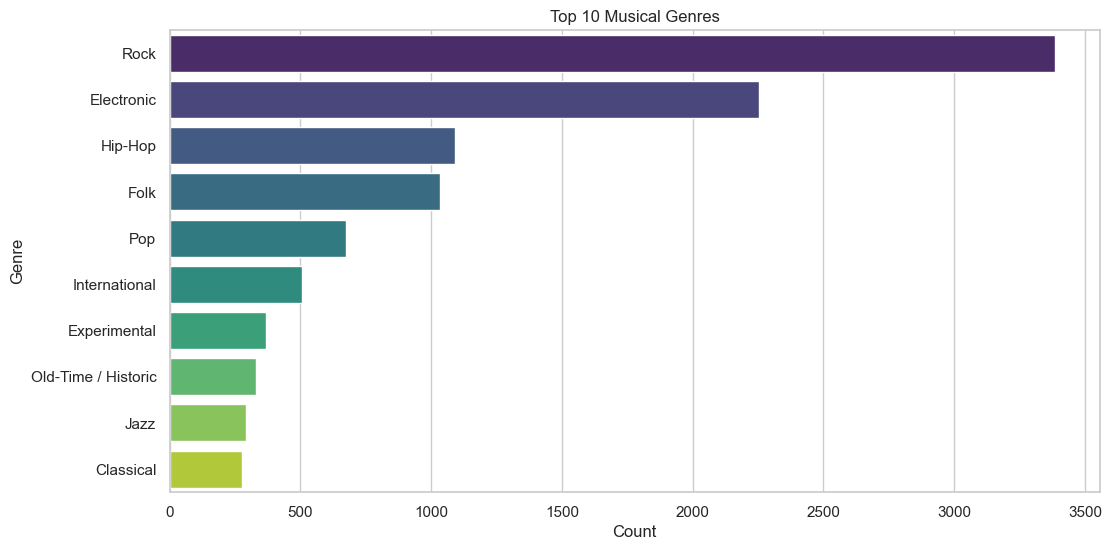

In [202]:
# Visualization of musical genre distribution
plt.figure(figsize=(12, 6))
genre_counts = df['genre_top'].value_counts().head(10)
print(genre_counts)
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Musical Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

- `Duplicates`: 0 duplicates in the dataframe

- `Inconsistencies`:
    - Duration, tempo, etc., are positive and reasonable (duration mean ~240s, max 3,016s).
    - Genres_all is a string list (e.g., '[21]'); we parse it with eval() for feature engineering.
    - No obvious outliers (e.g., energy between 0-1 as expected).
    - Imbalanced classes in genre_top